# 01c. Extended Temporal & Descriptive Analysis

Deeper analysis of temporal patterns, seasonal effects, rating drift,
review length trends, and group type evolution.

**Input:** `../Data/Processed/ushmm_tripadvisor_full_clean.csv`  
**Figures saved to:** `../Outputs/Figures/`

## Analyses
1. Rating over time — has evaluative sentiment shifted?
2. Review length over time — are reviews getting shorter?
3. Seasonal patterns — summer peak? January Remembrance Day?
4. Group type over time — has visitor composition changed?
5. Review title sentiment — quick signal from 100% complete field
6. Event window deep-dives — Charlottesville, Pittsburgh, Oct 7
7. Domestic vs international over time

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from collections import Counter

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [4]:
df = pd.read_csv("../Data/Processed/ushmm_tripadvisor_full_clean.csv",
                 parse_dates=["published_date"])

df["year"]    = df["published_date"].dt.year
df["month"]   = df["published_date"].dt.month
df["month_p"] = df["published_date"].dt.to_period("M")
df["review_length"] = df["review_text"].astype(str).str.len()

# English only for content analyses
en = df[df["lang"] == "en"].copy()

print(f"Full dataset: {len(df):,} rows")
print(f"English only: {len(en):,} rows")
print(f"Date range: {df['published_date'].min().date()} to {df['published_date'].max().date()}")

Full dataset: 11,367 rows
English only: 10,114 rows
Date range: 2002-11-30 to 2024-09-12


## 1. Rating Over Time

Has mean star rating shifted across the years?
A decline post-2016 would be consistent with political polarization;
a rise might reflect survivor generation passing and increased urgency.

In [5]:
# Annual mean rating (years with >=30 reviews for reliability)
annual_rating = (
    en.groupby("year")
      .agg(mean_rating=("rating", "mean"),
           n=("rating", "count"))
      .query("n >= 30")
)
print("Annual mean rating (years with ≥30 reviews):")
print(annual_rating.round(3).to_string())

Annual mean rating (years with ≥30 reviews):
      mean_rating     n
year                   
2011        4.648   162
2012        4.713   936
2013        4.677   888
2014        4.721  1010
2015        4.706  1715
2016        4.747  1753
2017        4.743  1472
2018        4.742  1090
2019        4.755   693
2020        4.873    71
2021        4.394    33
2022        4.171    70
2023        4.274    84
2024        4.750    36


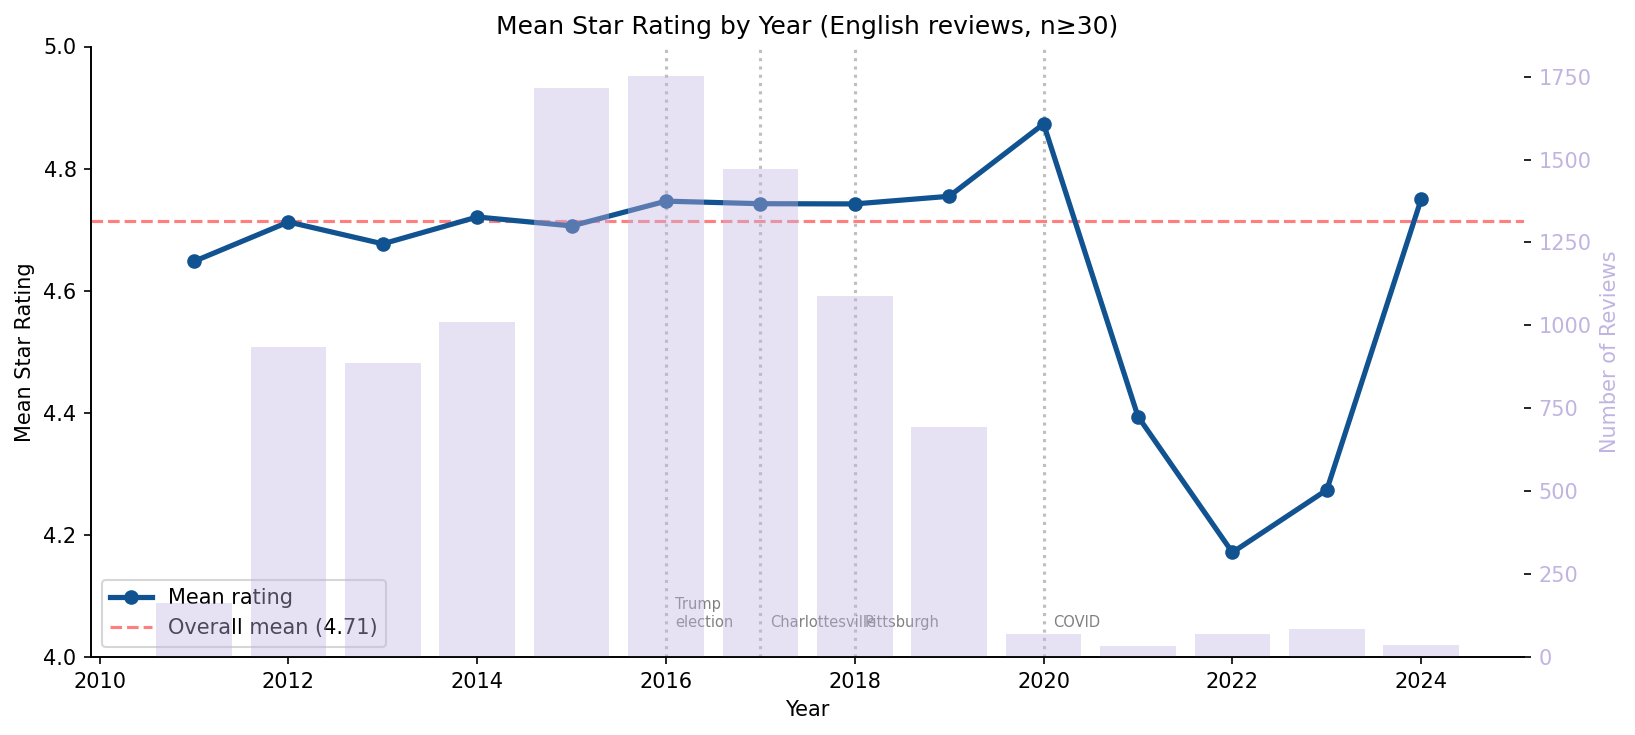

In [6]:
# Rating over time plot with volume as bar
fig, ax1 = plt.subplots(figsize=(11, 5))

ax2 = ax1.twinx()
ax2.bar(annual_rating.index, annual_rating["n"],
        color="#c1b4e1", alpha=0.4, label="Review count")
ax2.set_ylabel("Number of Reviews", color="#c1b4e1")
ax2.tick_params(axis="y", labelcolor="#c1b4e1")

ax1.plot(annual_rating.index, annual_rating["mean_rating"],
         color="#115391", linewidth=2.5, marker="o", zorder=5,
         label="Mean rating")
ax1.axhline(en["rating"].mean(), color="red", linestyle="--",
            alpha=0.5, label=f"Overall mean ({en['rating'].mean():.2f})")
ax1.set_ylim(4.0, 5.0)
ax1.set_ylabel("Mean Star Rating")
ax1.set_xlabel("Year")
ax1.legend(loc="lower left")

# Mark key events
for year, label in [(2016, "Trump\nelection"), (2017, "Charlottesville"),
                    (2018, "Pittsburgh"), (2020, "COVID")]:
    if year in annual_rating.index:
        ax1.axvline(year, color="gray", linestyle=":", alpha=0.5)
        ax1.text(year + 0.1, 4.05, label, fontsize=7, color="gray")

plt.title("Mean Star Rating by Year (English reviews, n≥30)")
plt.tight_layout()
plt.savefig("../Outputs/Figures/rating_over_time.png", dpi=300)
plt.show()

In [7]:
# 5-star share over time
five_star_share = (
    en.groupby("year")
      .apply(lambda x: (x["rating"] == 5).mean() * 100)
      .rename("pct_5star")
)
print("% of reviews that are 5-star, by year (years with ≥30 reviews):")
valid = annual_rating.index
print(five_star_share[five_star_share.index.isin(valid)].round(1).to_string())

% of reviews that are 5-star, by year (years with ≥30 reviews):
year
2011    76.5
2012    77.7
2013    76.1
2014    80.1
2015    79.8
2016    81.9
2017    81.6
2018    81.8
2019    84.6
2020    88.7
2021    72.7
2022    68.6
2023    60.7
2024    80.6


/tmp/ipykernel_6351/3004939044.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["rating"] == 5).mean() * 100)


## 2. Review Length Over Time

Are reviews getting shorter as mobile usage grows?
Does length vary by year independently of platform?

In [8]:
annual_length = (
    en.groupby("year")
      .agg(mean_length=("review_length", "mean"),
           median_length=("review_length", "median"),
           n=("review_length", "count"))
      .query("n >= 30")
)
print("Annual mean review length:")
print(annual_length.round(0).to_string())

Annual mean review length:
      mean_length  median_length     n
year                                  
2011        437.0          314.0   162
2012        413.0          282.0   936
2013        463.0          343.0   888
2014        461.0          327.0  1010
2015        410.0          309.0  1715
2016        412.0          318.0  1753
2017        425.0          316.0  1472
2018        420.0          313.0  1090
2019        429.0          320.0   693
2020        438.0          354.0    71
2021        334.0          309.0    33
2022        472.0          358.0    70
2023        482.0          348.0    84
2024        442.0          398.0    36


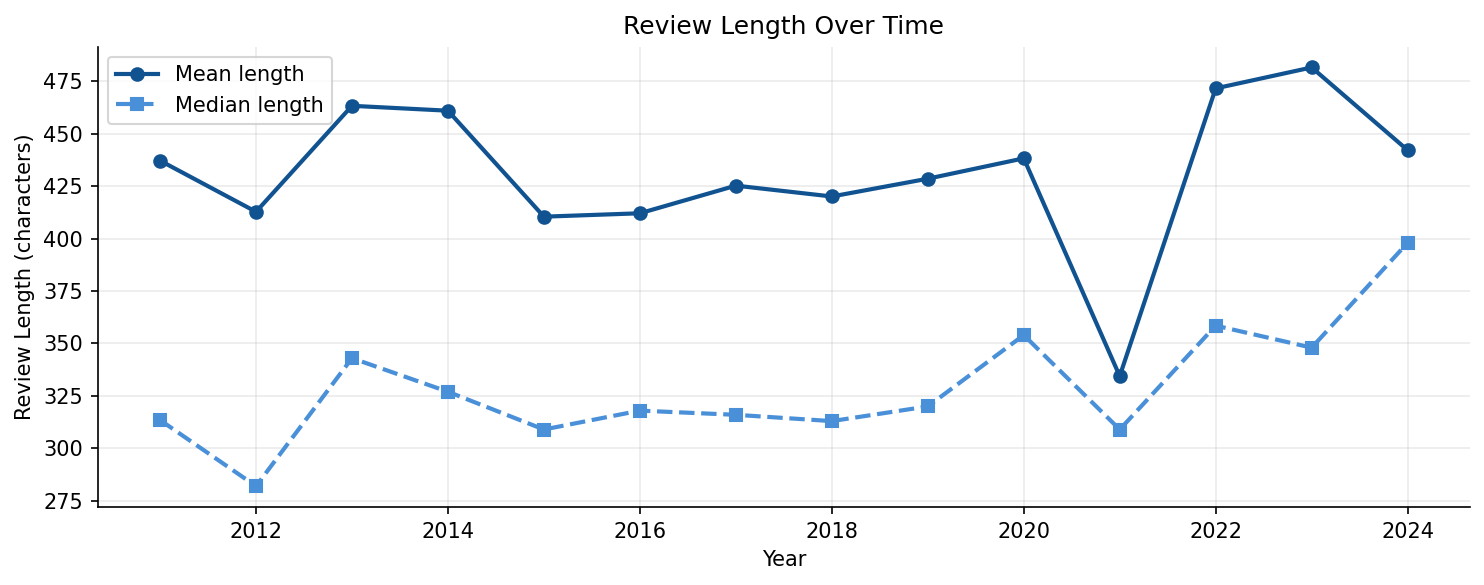

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(annual_length.index, annual_length["mean_length"],
        color="#115391", linewidth=2, marker="o", label="Mean length")
ax.plot(annual_length.index, annual_length["median_length"],
        color="#4a90d9", linewidth=2, linestyle="--",
        marker="s", label="Median length")
ax.set_xlabel("Year")
ax.set_ylabel("Review Length (characters)")
ax.legend()
ax.grid(alpha=0.25)
plt.title("Review Length Over Time")
plt.tight_layout()
plt.savefig("../Outputs/Figures/review_length_over_time.png", dpi=300)
plt.show()

## 3. Seasonal Patterns

TripAdvisor tourism reviews should peak in summer.
January 27 is International Holocaust Remembrance Day —
does January show any above-expected volume?

In [10]:
# Use only 2013-2018 for seasonal analysis
# (peak period with stable volumes; COVID years distort)
peak = en[en["year"].between(2013, 2018)].copy()

seasonal = (
    peak.groupby("month")
        .agg(mean_reviews=("rating", "count"),
             mean_rating=("rating", "mean"))
)
# Normalize by number of years
seasonal["avg_monthly_reviews"] = seasonal["mean_reviews"] / 6

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("Average monthly review volume (2013-2018):")
for m, row in seasonal.iterrows():
    print(f"  {month_names[m-1]:>3}: {row['avg_monthly_reviews']:.0f} reviews, "
          f"mean rating {row['mean_rating']:.3f}")

Average monthly review volume (2013-2018):
  Jan: 74 reviews, mean rating 4.789
  Feb: 58 reviews, mean rating 4.769
  Mar: 100 reviews, mean rating 4.711
  Apr: 132 reviews, mean rating 4.698
  May: 114 reviews, mean rating 4.706
  Jun: 130 reviews, mean rating 4.674
  Jul: 180 reviews, mean rating 4.650
  Aug: 149 reviews, mean rating 4.711
  Sep: 116 reviews, mean rating 4.774
  Oct: 114 reviews, mean rating 4.748
  Nov: 83 reviews, mean rating 4.808
  Dec: 71 reviews, mean rating 4.829


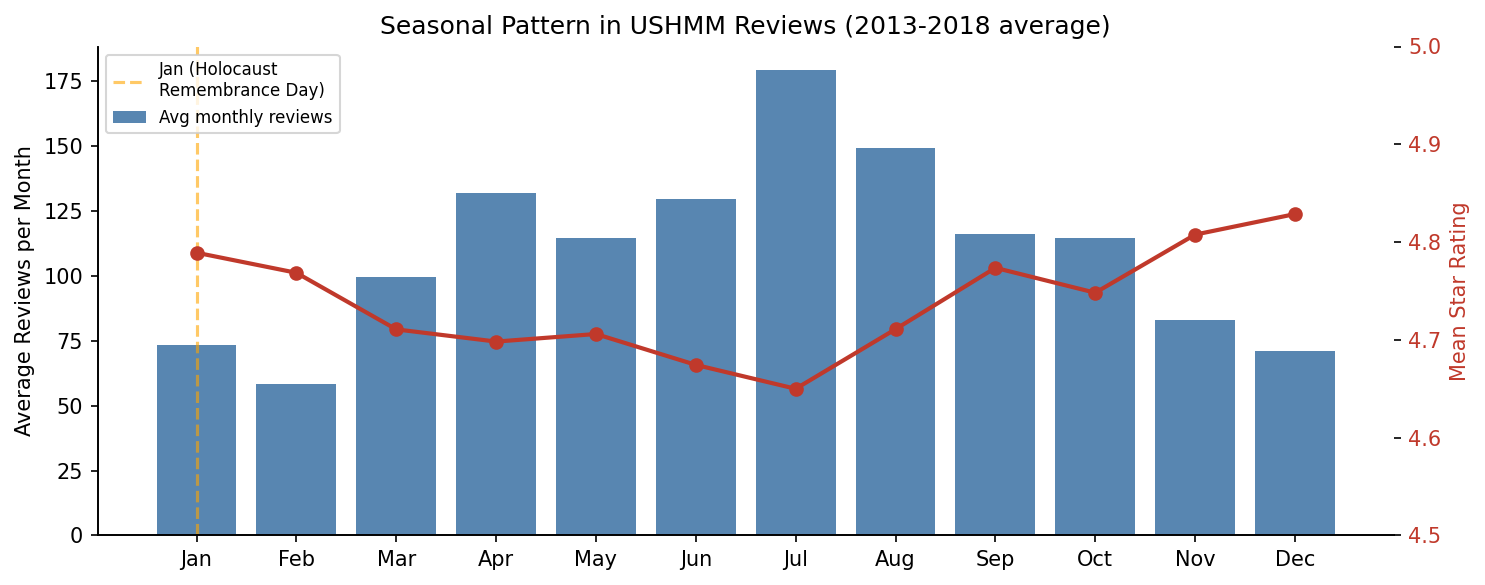

In [11]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(range(1, 13), seasonal["avg_monthly_reviews"],
        color="#115391", alpha=0.7, label="Avg monthly reviews")
ax2.plot(range(1, 13), seasonal["mean_rating"],
         color="#c0392b", linewidth=2, marker="o", label="Mean rating")

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_ylabel("Average Reviews per Month")
ax2.set_ylabel("Mean Star Rating", color="#c0392b")
ax2.tick_params(axis="y", labelcolor="#c0392b")
ax2.set_ylim(4.5, 5.0)

# Mark January (Holocaust Remembrance Day)
ax1.axvline(1, color="orange", linestyle="--", alpha=0.6,
            label="Jan (Holocaust\nRemembrance Day)")

ax1.legend(loc="upper left", fontsize=8)
plt.title("Seasonal Pattern in USHMM Reviews (2013-2018 average)")
plt.tight_layout()
plt.savefig("../Outputs/Figures/seasonal_pattern.png", dpi=300)
plt.show()

## 4. Group Type Over Time

Has the composition of visitor groups changed?
More solo visitors post-COVID? Fewer families?

In [12]:
# Group type share by year (peak years only for stability)
group_year = (
    en[en["year"].between(2013, 2019)]
      .dropna(subset=["group_type"])
      .groupby(["year", "group_type"])
      .size()
      .unstack(fill_value=0)
)
group_pct = group_year.div(group_year.sum(axis=1), axis=0) * 100

print("Group type share by year (%):")
print(group_pct.round(1).to_string())

Group type share by year (%):
group_type  BUSINESS  COUPLES  FAMILY  FRIENDS  NONE  SOLO
year                                                      
2013             5.5     28.5    36.5     15.7   4.9   9.0
2014             5.1     29.3    36.1     17.6   3.4   8.5
2015             5.6     26.8    33.7     13.8  11.9   8.3
2016             4.1     28.8    34.0     14.3   9.4   9.3
2017             3.2     30.0    35.2     12.6   9.7   9.3
2018             3.6     31.3    32.0     15.0   8.3   9.7
2019             2.7     24.0    27.6     10.8  27.3   7.6


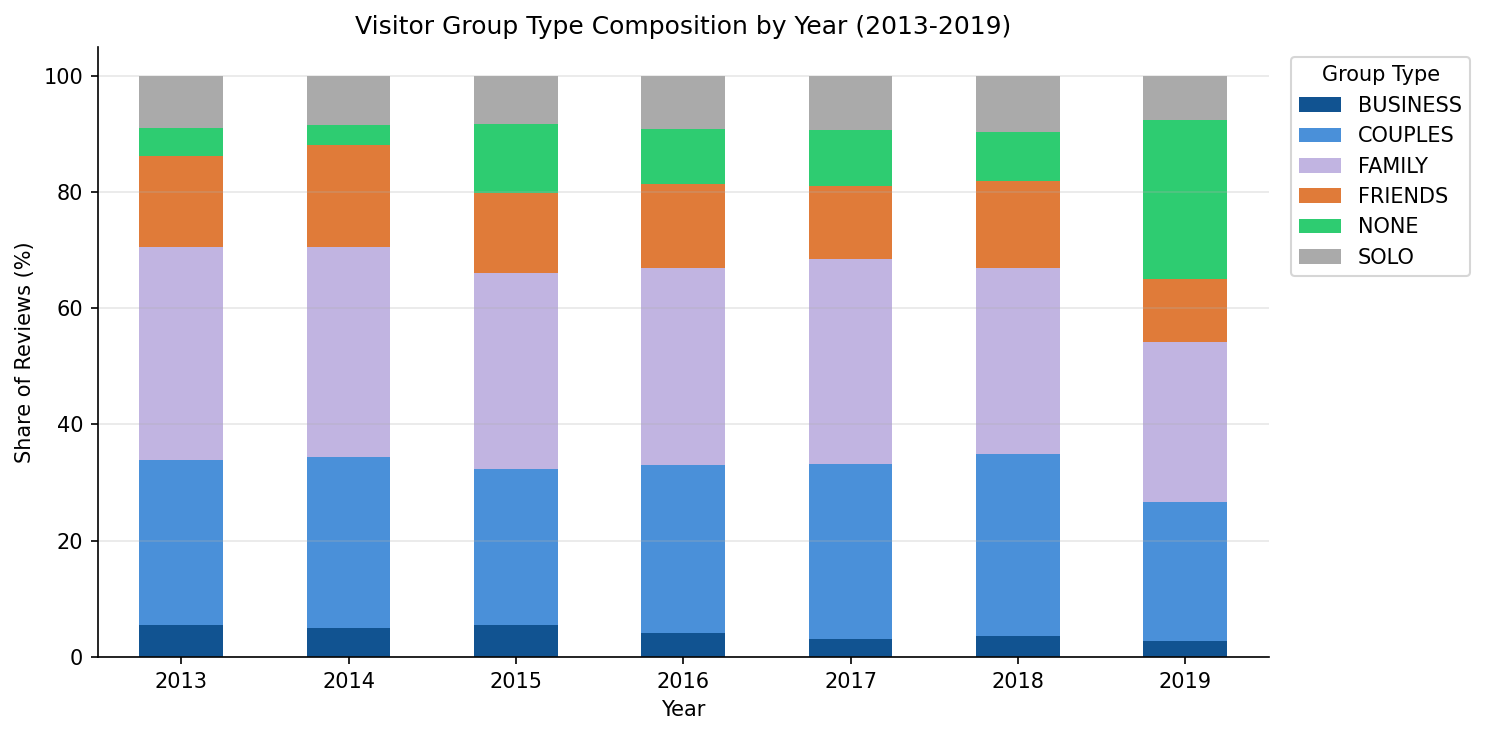

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#115391", "#4a90d9", "#c1b4e1", "#e07b39", "#2ecc71", "#aaaaaa"]
group_pct.plot(kind="bar", stacked=True, ax=ax,
               color=colors[:len(group_pct.columns)])
ax.set_xlabel("Year")
ax.set_ylabel("Share of Reviews (%)")
ax.set_xticklabels(group_pct.index, rotation=0)
ax.legend(title="Group Type", bbox_to_anchor=(1.01, 1))
ax.grid(axis="y", alpha=0.3)
plt.title("Visitor Group Type Composition by Year (2013-2019)")
plt.tight_layout()
plt.savefig("../Outputs/Figures/group_type_over_time.png", dpi=300)
plt.show()

In [14]:
# Rating by group type — does composition affect overall rating?
print("Mean rating and review length by group type:")
print(en.groupby("group_type")[["rating", "review_length"]]
        .agg(["mean", "count"])
        .round(2)
        .sort_values(("rating", "mean"), ascending=False))

Mean rating and review length by group type:
           rating       review_length      
             mean count          mean count
group_type                                 
BUSINESS     4.80   408        342.49   408
FRIENDS      4.77  1332        432.29  1332
SOLO         4.73   820        503.62   820
COUPLES      4.71  2663        419.53  2663
NONE         4.71  1303        415.25  1303
FAMILY       4.69  3207        432.58  3207


## 5. Event Window Deep-Dives

Monthly ratings and review lengths around key events.
Even if volume doesn't spike, does *content* shift?

In [15]:
events = {
    "Charlottesville (Aug 2017)": ("2017-05", "2017-12"),
    "Pittsburgh Synagogue (Oct 2018)": ("2018-07", "2019-03"),
    "Oct 7 Hamas (Oct 2023)": ("2023-07", "2024-06"),
}

en["month_p"] = en["published_date"].dt.to_period("M")

for event, (start, end) in events.items():
    window = en[
        (en["month_p"] >= start) & (en["month_p"] <= end)
    ].groupby("month_p").agg(
        n=("rating", "count"),
        mean_rating=("rating", "mean"),
        mean_length=("review_length", "mean")
    ).round(2)

    print(f"\n--- {event} ---")
    print(window.to_string())


--- Charlottesville (Aug 2017) ---
           n  mean_rating  mean_length
month_p                               
2017-05  137         4.73       436.45
2017-06  139         4.69       491.81
2017-07  193         4.62       453.55
2017-08  138         4.70       479.30
2017-09   98         4.86       439.98
2017-10  134         4.73       395.96
2017-11   85         4.88       351.53
2017-12   78         4.86       385.90

--- Pittsburgh Synagogue (Oct 2018) ---
           n  mean_rating  mean_length
month_p                               
2018-07  140         4.56       470.61
2018-08  117         4.75       443.72
2018-09   88         4.86       338.93
2018-10   96         4.74       367.17
2018-11   63         4.78       414.87
2018-12   53         4.89       315.45
2019-01   43         4.95       319.95
2019-02   42         4.83       441.31
2019-03   46         4.83       374.52

--- Oct 7 Hamas (Oct 2023) ---
          n  mean_rating  mean_length
month_p                           

## 6. Domestic vs International Over Time

In [16]:
us_states = [
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado",
    "Connecticut","Delaware","Florida","Georgia","Hawaii","Idaho",
    "Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana",
    "Maine","Maryland","Massachusetts","Michigan","Minnesota",
    "Mississippi","Missouri","Montana","Nebraska","Nevada",
    "New Hampshire","New Jersey","New Mexico","New York",
    "North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
    "Pennsylvania","Rhode Island","South Carolina","South Dakota",
    "Tennessee","Texas","Utah","Vermont","Virginia","Washington",
    "West Virginia","Wisconsin","Wyoming","District of Columbia"
]

def is_us(loc):
    if pd.isna(loc): return None
    return any(state in str(loc) for state in us_states)

en["is_domestic"] = en["reviewer_location"].apply(is_us)

geo_year = (
    en[en["year"].between(2013, 2019)]
      .dropna(subset=["is_domestic"])
      .groupby(["year", "is_domestic"])
      .agg(n=("rating", "count"), mean_rating=("rating", "mean"))
)

print("Domestic vs international by year (2013-2019):")
print(geo_year.round(3).to_string())

Domestic vs international by year (2013-2019):
                     n  mean_rating
year is_domestic                   
2013 False         153        4.660
     True          497        4.686
2014 False         188        4.697
     True          621        4.725
2015 False         284        4.577
     True         1028        4.730
2016 False         282        4.702
     True         1084        4.770
2017 False         209        4.722
     True          931        4.753
2018 False         177        4.774
     True          699        4.722
2019 False         101        4.713
     True          454        4.753


In [19]:
# International share over time
intl_share = (
    en[en["year"].between(2013, 2019)]
      .dropna(subset=["is_domestic"])
      .groupby("year")
      .apply(lambda x: (~x["is_domestic"]).mean() * 100, include_groups=False)
      .rename("pct_international")
)
print("International reviewer share by year (%):")
print(intl_share.round(1).to_string())

International reviewer share by year (%):
year
2013   -176.5
2014   -176.8
2015   -178.4
2016   -179.4
2017   -181.7
2018   -179.8
2019   -181.8


## 7. Summary of Key Findings

In [18]:
print("=" * 60)
print("SUMMARY OF KEY TEMPORAL FINDINGS")
print("=" * 60)

# Overall stats
print(f"\nDate range: {df['published_date'].min().date()} to {df['published_date'].max().date()}")
print(f"Peak year: {annual_rating['n'].idxmax()} "
      f"({annual_rating['n'].max():,} English reviews)")
print(f"Peak mean rating year: {annual_rating['mean_rating'].idxmax()} "
      f"({annual_rating['mean_rating'].max():.3f})")
print(f"Lowest mean rating year: {annual_rating['mean_rating'].idxmin()} "
      f"({annual_rating['mean_rating'].min():.3f})")

# COVID
pre = en[en["year"].between(2015, 2019)].shape[0]
covid = en[en["year"].between(2020, 2021)].shape[0]
print(f"\nCOVID impact: {pre:,} reviews (2015-19) → {covid} reviews (2020-21)")
print(f"Decline: {(1 - covid/pre)*100:.1f}%")

# Seasonal
peak_month = seasonal["avg_monthly_reviews"].idxmax()
print(f"\nPeak season: {month_names[peak_month-1]} "
      f"(avg {seasonal.loc[peak_month, 'avg_monthly_reviews']:.0f} reviews/year)")
print(f"January (Remembrance Day): avg "
      f"{seasonal.loc[1, 'avg_monthly_reviews']:.0f} reviews/year")

# Reviewer experience
print(f"\nMedian reviewer contributions: "
      f"{en['reviewer_total_contributions'].median():.0f}")
print(f"Power users (200+ contributions): "
      f"{(en['reviewer_total_contributions'] >= 200).mean()*100:.1f}%")

SUMMARY OF KEY TEMPORAL FINDINGS

Date range: 2002-11-30 to 2024-09-12
Peak year: 2016 (1,753 English reviews)
Peak mean rating year: 2020 (4.873)
Lowest mean rating year: 2022 (4.171)

COVID impact: 6,723 reviews (2015-19) → 104 reviews (2020-21)
Decline: 98.5%

Peak season: Jul (avg 180 reviews/year)
January (Remembrance Day): avg 74 reviews/year

Median reviewer contributions: 69
Power users (200+ contributions): 21.4%
